## IMPORTAMOS LIBRERIAS

In [ ]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import os
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Input,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score
)
from sklearn.cluster import KMeans

import umap

warnings.filterwarnings('ignore')

In [ ]:
import random

## SETEAMOS SEMILLA

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED) ## ResNet50 , Inception , EfficientNetB2 , Transformer
# from tensorflow.keras.applications import DenseNet121,ResNet50,EfficientNetB0,Xception


## CARGAMOS LA BASE DE DATOS

In [ ]:
# Crear la carpeta .kaggle si no existe
os.makedirs("/root/.kaggle", exist_ok=True)
# Mover el archivo kaggle.json a la carpeta
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# Dar permisos adecuados
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d carloscanamejoy/dataset-spines-complete

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-complete
License(s): apache-2.0
100% 468M/468M [00:02<00:00, 192MB/s]



In [ ]:
# Nombre del archivo descargado (ajústalo según sea necesario)
dataset_zip = "/content/dataset-spines-complete.zip"
# Extraer los archivos
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")
# Ver archivos extraídos
os.listdir("dataset")

['dataset-united.npz']

In [ ]:
file_ = '/content/dataset/dataset-united.npz'
data = np.load(file_)

print(data.files)

['img', 'params']


In [ ]:
data['img'].shape

(218256, 39, 39, 1)

In [ ]:
data['params'].shape

(218256, 8)

## PREPROCESAMIENTO

In [ ]:
X = np.copy(data['img'])
y = np.copy(data['params'])

## Definimos set de training, validation y testing

In [ ]:
from sklearn.model_selection import train_test_split

# test 15%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# validation 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1765, random_state=42
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

y_train_scaled = scaler.fit_transform(y_train)
y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [ ]:
def preprocess_batch(x):
    x = tf.image.resize(x, (224,224))
    x = tf.image.grayscale_to_rgb(x)
    return x

In [ ]:
BATCH_SIZE = 512

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

## DEFINIMOS EL MODELO XCEPTION

In [ ]:
# Definir la entrada
input_layer = Input(shape=(224, 224, 3))

# Modelo base
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

# Pooling global
x = GlobalAveragePooling2D()(base_model.output)

# Capa final de regresión (3 variables)
outputs = Dense(8, activation='linear')(x)

# Modelo final
model = Model(inputs=input_layer, outputs=outputs)

# Compilar
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add[0][0]       

 Total params: 20,877,872 (79.64 MB)

 Trainable params: 20,823,344 (79.43 MB)

 Non-trainable params: 54,528 (213.00 KB)

## ENTRENAMIENTO

In [ ]:
EPOCHS = 20

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 392s 799ms/step - loss: 0.0308 - mae: 0.1082 - val_loss: 0.0337 - val_mae: 0.1164 - learning_rate: 0.0010
Epoch 2/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - loss: 0.0218 - mae: 0.0864 - val_loss: 0.0269 - val_mae: 0.0964 - learning_rate: 0.0010
Epoch 3/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - loss: 0.0204 - mae: 0.0824 - val_loss: 0.0242 - val_mae: 0.0896 - learning_rate: 0.0010
Epoch 4/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - loss: 0.0193 - mae: 0.0796 - val_loss: 0.0253 - val_mae: 0.0928 - learning_rate: 0.0010
Epoch 5/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - loss: 0.0181 - mae: 0.0774 - val_loss: 0.0269 - val_mae: 0.0934 - learning_rate: 0.0010
Epoch 6/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 342ms/step - loss: 0.0167 - mae: 0.0743 - val_loss: 0.0262 - val_mae: 0.0928 - learning_rate: 0.0010
Epoch 7/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 103s 343ms/step - loss: 0.0151 - mae: 0.0705 - val_loss: 0.0267 - val_mae: 0.0937 - 

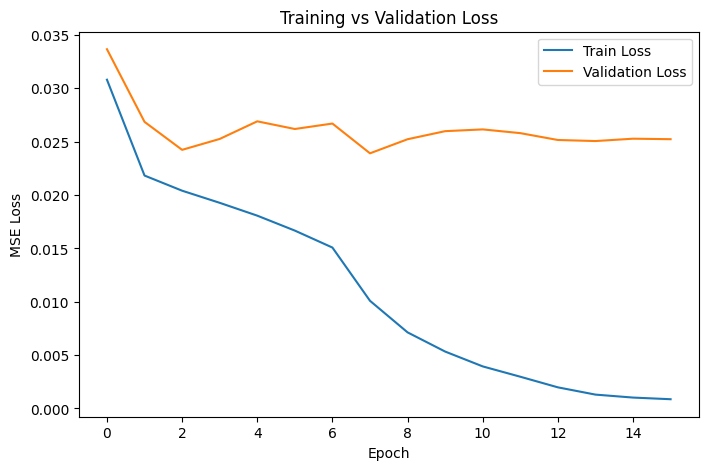

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

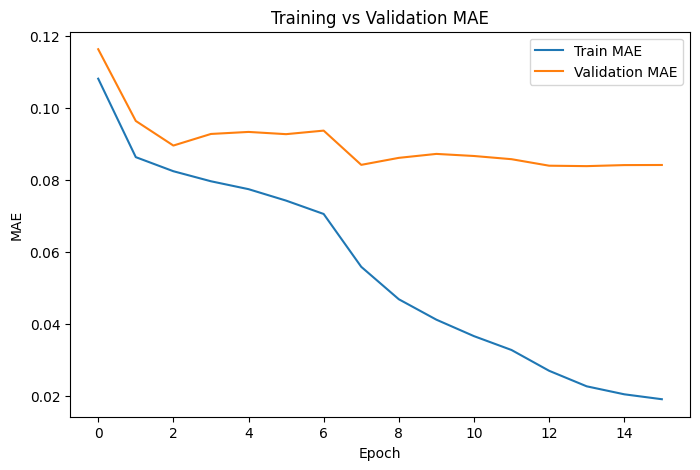

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

## GUARDAMOS LOS PESOS

In [ ]:
model.save('/content/drive/MyDrive/DoctoradoPaper1/modelo_xception_fulldatabaseV2.h5')

## EVALUAMOS RENDIMIENTO

In [ ]:
y_pred_scaled = model.predict(test_dataset)

# regresar a escala original
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test_scaled)

64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 861ms/step


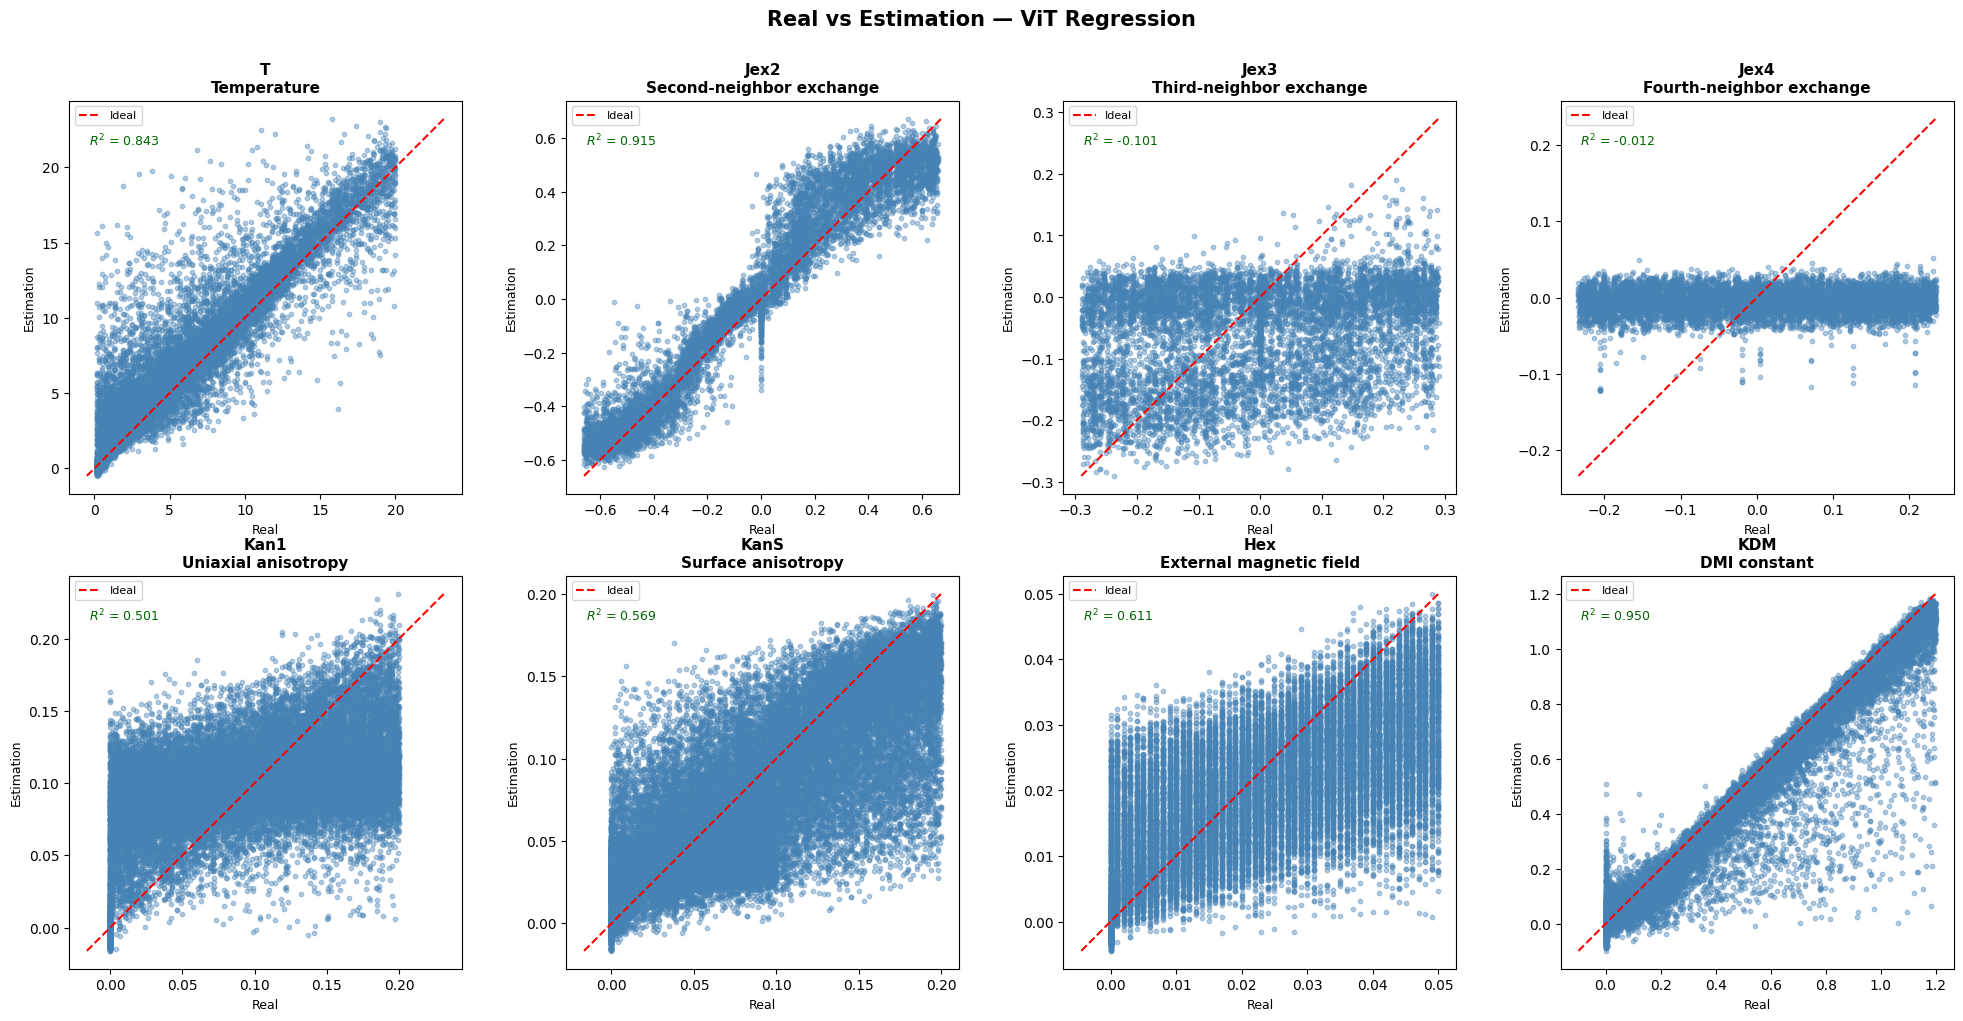

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]
descriptions = [
    "Temperature",
    "Second-neighbor exchange",
    "Third-neighbor exchange",
    "Fourth-neighbor exchange",
    "Uniaxial anisotropy",
    "Surface anisotropy",
    "External magnetic field",
    "DMI constant"
]

n_outputs = y_true.shape[1]
n_cols = 4
n_rows = int(np.ceil(n_outputs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i in range(n_outputs):
    ax = axes[i]

    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.4, s=10, color="steelblue")

    lims = [
        min(y_true[:, i].min(), y_pred[:, i].min()),
        max(y_true[:, i].max(), y_pred[:, i].max())
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label="Ideal")

    # R² por output
    ss_res = np.sum((y_true[:, i] - y_pred[:, i]) ** 2)
    ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.set_title(f"{param_names[i]}\n{descriptions[i]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Real", fontsize=9)
    ax.set_ylabel("Estimation", fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
            fontsize=9, color="darkgreen", verticalalignment='top')
    ax.set_aspect('equal', 'box')

# ocultar ejes sobrantes si n_outputs < n_cols * n_rows
for j in range(n_outputs, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Real vs Estimation — ViT Regression", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("vit_predictions_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## CALCULAMOS LAS METRICAS QUE REQUERIMOS

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

rows = []
for i, name in enumerate(param_names):
    mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2   = r2_score(y_true[:, i], y_pred[:, i])

    # MAPE — evitar división por cero
    mask = y_true[:, i] != 0
    mape = np.mean(np.abs((y_true[mask, i] - y_pred[mask, i]) / y_true[mask, i])) * 100

    rows.append({
        "Parameter": name,
        "MAE":  round(mae,  4),
        "RMSE": round(rmse, 4),
        "MAPE (%)": round(mape, 2),
        "R²":   round(r2,   4),
    })

df_metrics = pd.DataFrame(rows).set_index("Parameter")

# ordenar por R² descendente
df_metrics = df_metrics.sort_values("R²", ascending=False)

print(df_metrics.to_string())


              MAE    RMSE    MAPE (%)      R²
Parameter                                    
KDM        0.0493  0.0893   25.110001  0.9498
Jex2       0.0297  0.0556   65.389999  0.9146
T          0.8901  1.5537   40.450001  0.8430
Hex        0.0073  0.0104   79.230003  0.6107
KanS       0.0295  0.0388   87.940002  0.5686
Kan1       0.0347  0.0466  194.619995  0.5012
Jex4       0.0324  0.0681  117.529999 -0.0124
Jex3       0.0462  0.0884  171.979996 -0.1012


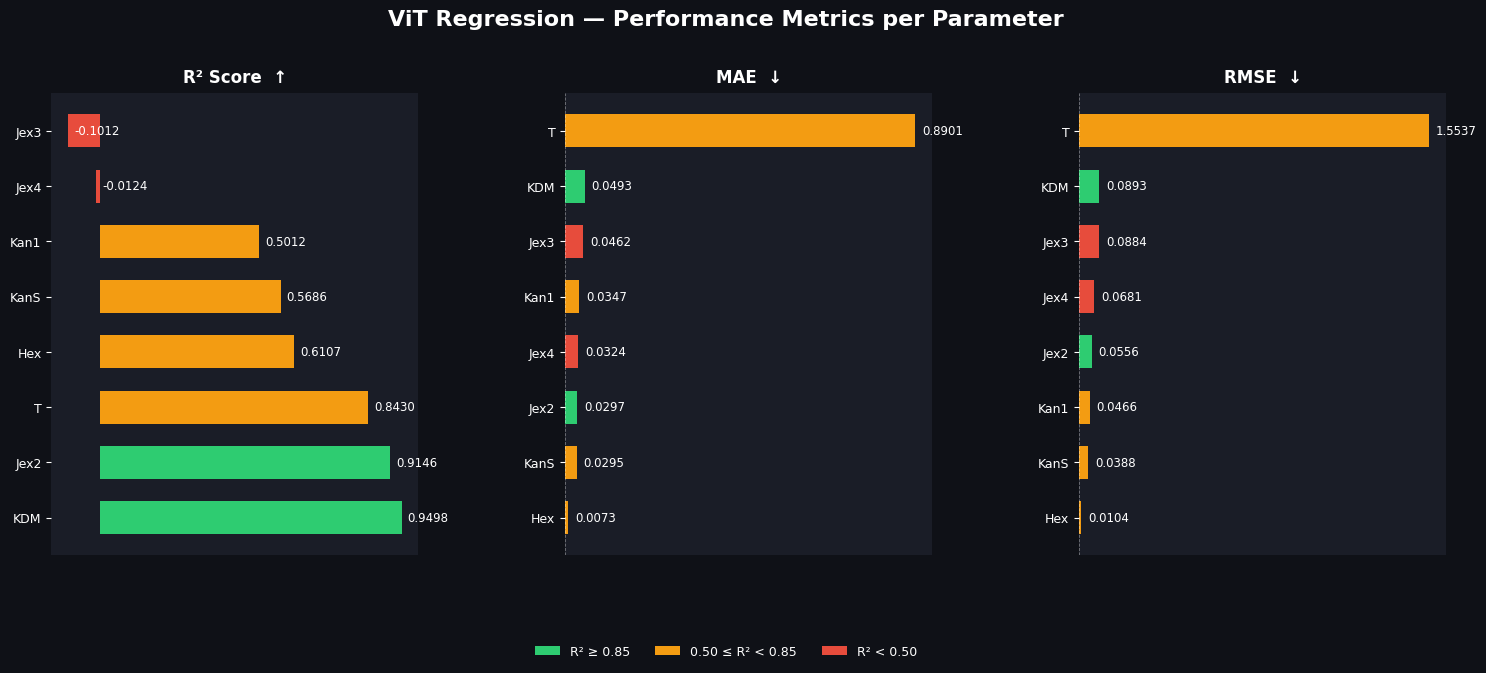

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

def get_color(r2):
    if r2 >= 0.85:   return "#2ecc71"
    elif r2 >= 0.5:  return "#f39c12"
    else:            return "#e74c3c"

colors = [get_color(df_metrics.loc[p, "R²"]) for p in param_names]

fig = plt.figure(figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("ViT Regression — Performance Metrics per Parameter",
             fontsize=16, fontweight="bold", color="white", y=1.02)

metrics = ["R²", "MAE", "RMSE"]
titles  = ["R² Score  ↑", "MAE  ↓", "RMSE  ↓"]

gs = gridspec.GridSpec(1, 3, wspace=0.4)

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor("#1a1d27")

    values = [df_metrics.loc[p, metric] for p in param_names]

    order = np.argsort(values)[::-1] if metric == "R²" else np.argsort(values)

    sorted_params = [param_names[i] for i in order]
    sorted_values = [values[i]      for i in order]
    sorted_colors = [colors[i]      for i in order]

    bars = ax.barh(sorted_params, sorted_values,
                   color=sorted_colors, edgecolor="none", height=0.6)

    ref = 1.0 if metric == "R²" else 0.0
    ax.axvline(ref, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

    for bar, val in zip(bars, sorted_values):
        ax.text(bar.get_width() + max(abs(v) for v in sorted_values) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left",
                color="white", fontsize=8.5)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=8)
    ax.tick_params(colors="white", labelsize=9)
    ax.spines[:].set_visible(False)
    ax.xaxis.set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="R² ≥ 0.85"),
    Patch(facecolor="#f39c12", label="0.50 ≤ R² < 0.85"),
    Patch(facecolor="#e74c3c", label="R² < 0.50"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           frameon=False, fontsize=9,
           labelcolor="white", bbox_to_anchor=(0.5, -0.08))

plt.savefig("vit_metrics_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()